# Analytical posterior for the mean and variance of a normal distribution
This notebook intends to provide some general feeling on how Bayesian inference works for simple use-cases and distributions.
The main interest is in how the addition of new samples improves the posterior predictive distribution.
We can compare the Bayesian estimates to those from a frequentists approach.
For these simple distributions we can easily find when a Bayesian approach works best compared to a frequentist one.

Authors: R.P. Krijnen, M. Peirlinck  
(C) Peirlinck Lab, Delft University of Technology, 2025  
Correspondence: mplab-me@tudelft.nl  

Github: https://github.com/peirlincklab



In [20]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.special import gamma, gammaln
from scipy.integrate import quad
from IPython.display import HTML

from matplotlib.animation import FuncAnimation

from BI_WS01_utilities import UpdateDist, plot_distributions

## Useful constants 
We define constants for the prior, likelihood and true/underlying distribution

In [21]:
# Define constants
TRUE_MEAN = 1.0 #Mean of the underlying distribution
TRUE_SCALE = 0.4 # Variance of the underlying distribtution


M0=0.0 #mean of the prior
V0 = 0.7 #scale of the prior

A = 2 # scale parameter of the Inverse Gamma distribution
B = 2 # rate parameter of the Inverse Gamma distribution

NR_MEASUREMENTS = 100

np.random.seed(314159)

## Define the probability density functions
We define the PDFs for a normal distribution and derive the prior, likelihood and true/underlying distribution of the measurements.
Be careful!!! the scale parameter is $\sigma$ a.k.a. the standard deviation. In the definitions below we use the variance $\sigma^2$.

#### prior:
$$
\begin{aligned}
& \begin{aligned}
p\left(\mu, \sigma^2\right) & =\mathrm{NIG}\left(m_0, V_0, a_0, b_0\right) \\
& =\mathcal{N}\left(\mu \mid m_0, \sigma^2 V_0\right) I G\left(\sigma^2 \mid a_0, b_0\right)
\end{aligned}
\end{aligned}
$$

#### likelihood:
$$
\begin{aligned}
& p\left(y \mid \mu, \sigma^2\right)=\frac{1}{(2 \pi)^{n / 2}}\left(\sigma^2\right)^{-n / 2} \exp \left(-\frac{1}{2 \sigma^2}\left[n s^2+n(\bar{y}-\mu)^2\right]\right) \\
\end{aligned}
$$

#### Bayes theorem:
$$p(\mu|y) = \frac{p(y|\mu)p(\mu)}{p(y)}$$

#### Joint distributions:
$$p(\mu,y) = p(y|\mu)p(\mu) = p(\mu|y)p(y)$$

#### Marginalization:
$$p(y) = \int p(\mu,y)d\mu $$

#### Posterior predictive:
$$
\begin{aligned}
&  \\
& \begin{aligned}

\end{aligned}
\end{aligned}
$$
$$
\begin{aligned}
p\left(\mu, \sigma^2 \mid y\right) & =N I G\left(m_n, V_n, a_n, b_n\right) \\
V_n^{-1} & =V_0^{-1}+n \\
\frac{m_n}{V_n} & =V_0^{-1} m_0+n \bar{x} \\
a_n & =a_0+n / 2 \\
b_n & =b_0+\frac{1}{2}\left[m_0^2 V_0^{-1}+\sum_i y_i^2-m_n^2 V_n^{-1}\right]
\end{aligned}
$$

$$
p(x \mid y)=t_{2 a_n}\left(m_n, \frac{b_n\left(1+V_n\right)}{a_n}\right)
$$
Where $t_{2 a_n}$ is a general student-t distribution.

## First we will define some  probability density functions
Namely those of the normal distribution, inverse-gamma distribution, the normal-inverse-gamma distribution and the student-t distribution.

In [22]:
def normal_pdf(x, loc:float=0.0, scale:float=1.0):
    """Implementation of the normal distribution's PDF. 
        x: draw from the domain of the distribution
        loc: mean of the distribution
        scale: the standard deviation of the distribution"""
    normalizer = (1/(2*np.pi*scale**2))**(1/2)
    return (normalizer*np.exp(-(1/(2*scale**2))*(x-loc)**2)).squeeze()

def inv_gamma_pdf(x, alpha=1, beta=1):
    """Implementation of the inverse-gamma PDF. 
        x: draw from the domain of the distribution
        alpha: shape parameter
        beta: rate parameter"""
    assert alpha > 0
    assert beta > 0
    return (beta**alpha / gamma(alpha)) * (x)**(-(alpha+1)) * np.exp(-beta/x)

def normal_inverse_gamma_pdf(draws_mu:np.array, draws_sig:np.array, loc, scale, a, b):
    """A naive implementation of the normal inverse gamma distribution.
        draws_mu: draw from the domain of the distribution for the mean
        draws_sigma: draw from the domain of the distribution for the scale
        loc: mean of the normal distribution
        scale: the standard deviation of the normal distribution
        alpha: shape parameter of the inverse-gamma distribution
        beta: rate parameter of the inverse-gamma distribution"""
    return normal_pdf(draws_mu, M0, V0)*inv_gamma_pdf(draws_sig, A, B)

def student_t_pdf(x, v, mu, sigma, reformulated=True):
    """Implementation of the student-t distribution as found in Murphy 2007.
        A small reformulation has been implemented to make it more numerically stable when we include a large number of observations.
        x: draw from the domain of the distribution
        v: a scalar value for a shape like parameter in Murphy's student-t distribution 
        mu: scalar value for the "mean" of the student-t distribution 
        sigma: scalar value for thhe "variance" of the student-t distribution 
        reformulated: Boolean indicator for the use of the reformulated or the naive implementation"""
    assert v > 0
    if reformulated:
        c = np.exp((gammaln(v/2 + 1/2)) - (gammaln(v/2))) * ((1) / (np.sqrt(v*np.pi)*sigma))
    else:
        c = ((gamma(v/2 + 1/2)) / (gamma(v/2))) * ((1) / (np.sqrt(v*np.pi)*sigma)) # catch numerical errors with gamma(v/2) =~ inf and gamma(v/2+0.5)/gamma(v/2) =~ 1
    return c * (1 + (1/v)*((x-mu)/sigma)**2)**(-(v+1)/2)

## The true distribution 

In [23]:
def true_pdf(draws:np.array, loc=TRUE_MEAN, scale=TRUE_SCALE):
    """Returns draws from a normal distribution using the parameters of the true distribution."""
    return normal_pdf(x=draws, loc=loc, scale=scale)

def true_pdf_sampler(n_samples:int=100, loc=TRUE_MEAN, scale=TRUE_SCALE):
    """A function which draws n_samples from the true distribution so that we can simulate measurements."""
    return np.random.normal(loc=loc, scale=scale, size=(n_samples,)).reshape(n_samples, 1)

## The prior distribution

In [24]:
def prior_pdf(draws_mu:np.array, draws_sig:np.array, loc=M0, scale=V0, a=A, b=B):
    """Pass constants to the normal inverse gamma distribution"""
    return normal_pdf(draws_mu, loc, scale)*inv_gamma_pdf(draws_sig, a, b)

def marginalized_prior_pdf(draws_mu:np.array, loc=M0, scale=V0, a=A, b=B):
    """A marginalized version of the prior where we marginalize out the variance to visualize the prior."""
    return normal_pdf(draws_mu, loc, scale)*quad(inv_gamma_pdf, 0, np.inf, args=(a, b))[0]

## The posterior distribution

In [25]:
def posterior_pdf(draws_mu:np.array, draws_sigma:np.array, y:np.array, prior_loc=M0, prior_scale=V0, prior_shape=A, prior_rate=B):
    """Implementation of the posterior PDF. Because this example makes use of conjugate 
        prior and likelihood distributions, there exists an analytical form of the posterior.
    """
    n = len(y)
    y_bar = np.mean(y)
    sigma2_n = 1/(1/prior_scale**2 + n)
    m_n = sigma2_n*((1/prior_scale**2)*prior_loc + n*y_bar)
    a_n = prior_shape + n/2
    b_n = prior_rate + 0.5*(prior_loc**2 / prior_scale**2 + np.sum(y**2) - m_n**2 / sigma2_n)
    return stats.normal_inverse_gamma.pdf(draws_mu, draws_sigma, mu=m_n, lmbda=sigma2_n, a=a_n, b=b_n)

def posterior_predictive_pdf(draws:np.array, y, prior_loc=M0, prior_scale=V0, prior_shape=A, prior_rate=B):
    """The posterior predictive distribution, which in this case is simply a scaled version of the posterior using the true variance."""
    n = len(y)
    y_bar = np.mean(y)

    V_n_1 = 1/prior_scale + n
    V_n = V_n_1**-1
    m_n = V_n*((1/prior_scale)*prior_loc + n*y_bar)
    
    a_n = prior_shape + n/2
    b_n = prior_rate + 0.5*(prior_loc**2 / prior_scale + np.sum(y**2) - V_n_1*m_n**2)
    return student_t_pdf(draws, 2*a_n, m_n, np.sqrt((b_n*(1+V_n))/a_n))

## Let's try to do inference with few available samples (10)
Notice the use of lambda in the passing of the distributions into this plot_distributions function.
Lambda basically allows you to simplify the arguments that you pass into the function.
Doing this allows us to change the global variables such as ```NR_MEASUREMENTS``` and ```TRUE_MEAN```, which are passed as default values into the corresponding pdf functions.

c:\Users\rogie\surfdrive\Python_Scripts\vital202503_BI\new_material\BI_WS01_utilities.py:133: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  stationary_fig.show()


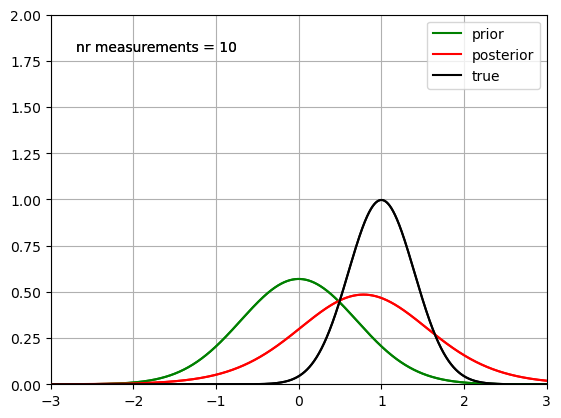

In [26]:
NR_MEASUREMENTS = 10

plot_distributions(NR_MEASUREMENTS, 
            true_pdf=lambda x: true_pdf(x, loc=TRUE_MEAN, scale=TRUE_SCALE), 
            true_pdf_sampler=lambda x: true_pdf_sampler(x, loc=TRUE_MEAN, scale=TRUE_SCALE), 
            marginalized_prior=lambda x: marginalized_prior_pdf(x, loc=M0, scale=V0, a=A, b=B), 
            posterior_predictive=lambda x, y: posterior_predictive_pdf(x, y, prior_loc=M0, prior_scale=V0, prior_shape=A, prior_rate=B))

## We can animate the behavior

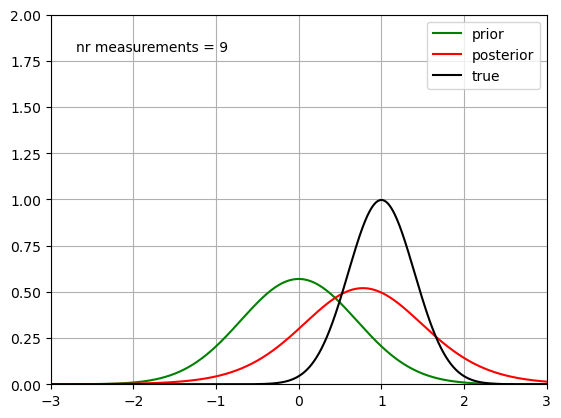

In [27]:
fig, ax = plt.subplots()
ud = UpdateDist(ax, NR_MEASUREMENTS, 
                true_pdf=true_pdf, 
                true_pdf_sampler=true_pdf_sampler, 
                marginalized_prior=marginalized_prior_pdf, 
                posterior_predictive=posterior_predictive_pdf)
anim = FuncAnimation(fig, ud, init_func=ud.start, frames=NR_MEASUREMENTS, interval=100, blit=True)
# anim.save("Bayesian_update.gif", dpi=300, writer=PillowWriter(fps=10))
HTML(anim.to_jshtml())

# Let's try to do inference using a modest amount of samples 
Pick any value you want (as long as it's an integer)

In [ ]:
NR_MEASUREMENTS = ...

plot_distributions(NR_MEASUREMENTS, true_pdf=lambda x: true_pdf(x, loc=TRUE_MEAN, scale=TRUE_SCALE), 
                                true_pdf_sampler=lambda x: true_pdf_sampler(x, loc=TRUE_MEAN, scale=TRUE_SCALE), 
                                marginalized_prior=lambda x: marginalized_prior_pdf(x, loc=M0, scale=V0, a=A, b=B), 
                                posterior_predictive=lambda x, y: posterior_predictive_pdf(x, y, prior_loc=M0, prior_scale=V0, prior_shape=A, prior_rate=B))



## Let's investigate the influence of the prior
We can choose prior mean and variances that are uninformative (very large variance), or very informative priors (low variance).
Plot the resulting posterior when we have highly informative and uninformative prior distributions.

You can also check what happens when these distributions have 'wrong' mean values e.g. at the bounds of our plot.

In [ ]:
M0 = ... #mean of the prior
V0 = ... #scale of the prior

A = ... # scale parameter of the Inverse Gamma distribution
B = ... # rate parameter of the Inverse Gamma distribution

plot_distributions(NR_MEASUREMENTS, true_pdf=lambda x: true_pdf(x, loc=TRUE_MEAN, scale=TRUE_SCALE), 
                                true_pdf_sampler=lambda x: true_pdf_sampler(x, loc=TRUE_MEAN, scale=TRUE_SCALE), 
                                marginalized_prior=lambda x: marginalized_prior_pdf(x, loc=M0, scale=V0, a=A, b=B), 
                                posterior_predictive=lambda x, y: posterior_predictive_pdf(x, y, prior_loc=M0, prior_scale=V0, prior_shape=A, prior_rate=B))

## What happens when we have little and a lot of measurements available?
Check what happens when we have uninformative priors and 'wrong' priors when we have few and many measurements available.
When does the posterior converge?

In [ ]:
M0 = ... #mean of the prior
V0 = ... #scale of the prior

A = ... # scale parameter of the Inverse Gamma distribution
B = ... # rate parameter of the Inverse Gamma distribution

plot_distributions(NR_MEASUREMENTS, true_pdf=lambda x: true_pdf(x, loc=TRUE_MEAN, scale=TRUE_SCALE), 
                                true_pdf_sampler=lambda x: true_pdf_sampler(x, loc=TRUE_MEAN, scale=TRUE_SCALE), 
                                marginalized_prior=lambda x: marginalized_prior_pdf(x, loc=M0, scale=V0, a=A, b=B), 
                                posterior_predictive=lambda x, y: posterior_predictive_pdf(x, y, prior_loc=M0, prior_scale=V0, prior_shape=A, prior_rate=B))